# Applied Data Science and Machine Learning
## A program by IIT Madras and TalentSprint
### Mini Project Notebook: Stock Prices Anomaly Detection

## Learning Objectives

At the end of the experiment, you will be able to :

* apply PCA based analysis on various stocks data
* analyze and create time series data
* implement LSTM auto-encoders
* detect the anomalies based on the loss


## Information

Autoencoder Neural Networks try to learn data representation of its input. Usually, we want to learn an efficient encoding that uses fewer parameters/memory. The encoding should allow for output similar to the original input. In a sense, we’re forcing the model to learn the most important features of the data using as few parameters as possible.

LSTM autoencoder is an encoder that makes use of LSTM encoder-decoder architecture to compress data using an encoder and decode it to retain original structure using a decoder.

**Anomaly Detection**

Anomaly detection refers to the task of finding/identifying rare events/data points. Some applications include - bank fraud detection, tumor detection in medical imaging, and errors in written text.

A lot of supervised and unsupervised approaches for anomaly detection have been proposed. Some of the approaches include - One-class SVMs, Bayesian Networks, Cluster analysis, and Neural Networks.

We will use an LSTM Autoencoder Neural Network to detect/predict anomalies (sudden price changes) in the S&P 500 index.

## Dataset



This mini-project consists of two parts and two different stock price datasets:

### PART A

Using the **S&P 500 stock prices data of different companies**, we will perform a PCA based analysis.

### PART B

Using the **S&P 500 stock price index time series data**, we will perform anomaly detection in the stock prices across the years. The dataset chosen is is S&P500 Daily Index a .csv format with one column with a daily timestamp and the second column with the raw, un-adjusted closing prices for each day. This long term, granular time series dataset allows researchers to have a good sized publicly available financial dataset to explore time series trends or use as part of a quantitative finance project.

## Problem Statement

Detect the stock price anomalies by implementing an LSTM autoencoder

## Grading = 10 Points

In [ ]:
#@title Download dataset
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/SPY.csv
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/prices.csv

### Import required packages

In [ ]:
import keras
from keras.layers import Activation, Dense, Dropout, Flatten
from keras.layers import LSTM, RepeatVector, TimeDistributed
from keras.layers import BatchNormalization
from keras.models import Sequential, Model
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

## PCA Analysis (PART-A)

Principal Component Analysis (PCA) decomposes the data into many vectors called principal components. These summaries are linear combinations of the input features that try to explain as much variance in the data as possible. By convention, these principal components are ordered by the amount of variance they can explain, with the first principal component explaining most of the data.

Perform PCA based analytics on the stock prices data from different companies.

Hint: Refer to the article [here](https://towardsdatascience.com/principal-component-analysis-pca-79d228eb9d24).

### Load and pre-process the prices data (1 points)

In [ ]:
prices_path = "prices.csv"
#Create a dataframe from the data
df_prices=pd.read_csv(prices_path)

In [ ]:
#Lets Explore the dataset
display(df_prices.shape)                          #394 Rows, 503 Colums
print("\033[95m]========================================================================HEAD=============================================================================================================================================\033[0m")
display( df_prices.head())   #1st row shows as null, we will figure out how to handle that
print("\033[95m]========================================================================DESCRIBE=============================================================================================================================================\033[0m")
display(df_prices.describe())
print("\033[95m]========================================================================NULL COUNTS=============================================================================================================================================\033[0m")
display(df_prices.isnull().sum())

(394, 503)

]========================================================================HEAD=============================================================================================================================================


,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,85.017082,28.982893,157.171890,74.207466,81.950539,82.938141,168.809998,84.622925,204.910950,334.429993,...,59.934875,100.115349,63.633118,56.203197,78.396255,99.349007,147.579269,259.140015,49.903751,132.803421
2,83.652077,27.548195,157.181747,73.486023,81.172668,81.895088,166.820007,83.591301,204.569687,331.809998,...,60.223114,97.810677,63.121540,55.581242,78.857689,99.037834,147.193512,256.049988,49.199547,132.823227
3,83.899353,27.219410,154.598541,74.071579,81.813271,83.094116,179.039993,84.029251,203.233841,333.709991,...,60.136642,95.771927,63.606186,55.887280,78.347168,98.979500,146.342834,258.010010,48.600010,131.803482
4,84.156532,27.119778,152.764648,73.723213,81.346550,82.499466,180.350006,83.562103,198.846008,333.390015,...,60.011738,97.958405,63.085632,56.183449,78.052628,99.154533,146.214264,256.470001,48.305000,132.248978


]========================================================================DESCRIBE=============================================================================================================================================


,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
count,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,...,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000
mean,106.171822,17.292796,155.247315,107.517655,94.129335,100.486826,262.254962,102.504811,233.243117,447.628983,...,65.178093,112.049354,46.498890,51.854965,89.292116,98.902011,143.144424,342.530662,41.111383,152.978500
std,22.977011,5.558969,28.536061,24.950575,13.315335,11.605022,60.671532,14.198241,40.376496,74.091110,...,4.206889,21.685100,10.203772,9.418061,18.164872,13.567085,20.139871,113.482293,10.676190,19.901649
min,62.682178,9.040000,74.185577,55.566658,59.823822,72.386261,130.509995,61.398403,140.649490,285.000000,...,48.351284,68.233444,28.631767,31.492746,55.780792,55.205753,79.754128,161.509995,23.084974,91.869362
25%,86.532539,12.530000,139.690811,80.040680,83.219566,92.947746,206.160004,89.737274,204.569687,382.170013,...,62.440845,93.880013,38.928276,43.843239,73.910576,89.683189,132.405899,251.990005,31.449303,137.159546
50%,103.416412,16.040001,152.869995,116.028427,91.866768,98.649742,276.140015,105.797867,232.967743,465.459991,...,65.670860,112.089996,43.207108,51.386478,87.490585,100.586731,146.985809,286.739990,40.628784,157.493118
75%,125.124901,21.820000,170.652969,127.402893,104.871559,109.170837,310.820007,115.490318,260.128387,493.140015,...,68.227661,130.350006,55.875996,59.747906,102.314072,106.934402,159.027481,471.970001,51.399727,163.987946
max,152.309998,30.469999,214.949997,149.149994,118.190002,125.386459,355.130005,127.276352,318.649994,625.869995,...,73.184013,152.110001,64.660004,69.001335,123.260002,122.790001,178.349243,548.609985,60.270000,203.589996


]========================================================================NULL COUNTS=============================================================================================================================================


,0
A,1
AAL,1
AAP,1
AAPL,1
ABBV,1
...,...
YUM,1
ZBH,1
ZBRA,1
ZION,1


In [ ]:
display(df_prices.isnull().sum().sum())     #There are total 953 Nulls. The first row entirely is null and there are some coulmns which do not have all the data.

#Print the rows where there are no values.
nan_rows = df_prices[df_prices.isna().all(axis=1)]
display(nan_rows)                                            # The row with index 0 is fully null, lets drop this.
df_prices=df_prices.dropna(how='all')                        # Dropping the rows where all the columns are blank. This should remove the first row or row with 0 index from the dataset.
display(df_prices.shape)                                     # 393*503 is the new shape after dropping 1 row.

np.int64(953)

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(393, 503)

In [ ]:
#After dropping the null row. lets see if there are any other nulls present.
display(df_prices.isnull().sum().sum())                      #450 are still left these must be some where in the columns, lets replace them with the column average i.e. the avg. price of the stock over the period.
df_prices=df_prices.fillna(df_prices.mean())                 # replacing the NAN with the mean prices for that stock.
display(df_prices.isnull().sum().sum())                      # Show 0 null values now.

np.int64(450)

np.int64(0)

In [ ]:
#Standardizing the data by using Standard Scaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df_prices)
np.isnan(scaled_data).any()                         #Saftey check for any nulls post the scaling.
scaled_data.shape

(393, 503)

### Apply PCA (2.5 points)

* plot the explained variance ratio. Hint: `pca.explained_variance_ratio_`
* Represent the components which preserve maximum information and plot to visualize
* Compute the daily returns of the 500 company stocks.
* Discuss the least and most impacted industrial sectors in terms of stocks.

In [ ]:
pca=PCA()
vectors=pca.fit_transform(scaled_data)
display(vectors.shape)                                                       #393 principal components as the matrix is of size 393*503, so maximum number of possible non-zero eigen values is 393 and hence 393 PC's, with 393 data points projected on them.


(393, 393)

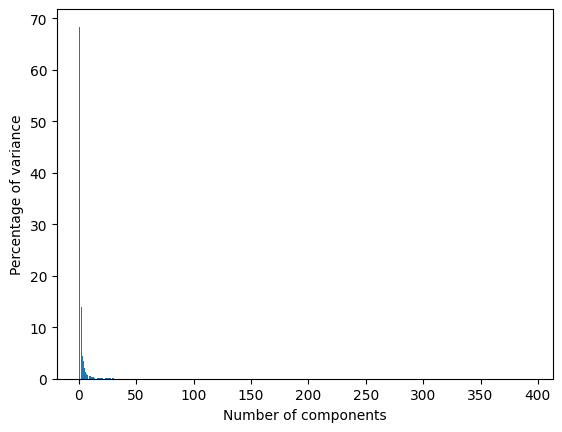

In [ ]:
#plot the explained variance ratio. Hint: pca.explained_variance_ratio_
variance=pca.explained_variance_ratio_
variance_sorted=sorted(variance,reverse=True)

# Finding the variance between the each principal component
tot = sum(variance)
var_exp = [(i / tot)*100 for i in sorted(variance, reverse=True)]
plt.bar(range(1,len(var_exp)+1), var_exp)
plt.xlabel('Number of components')
plt.ylabel('Percentage of variance')                                                                 #1st component itself represent the 68%of data.
plt.show()

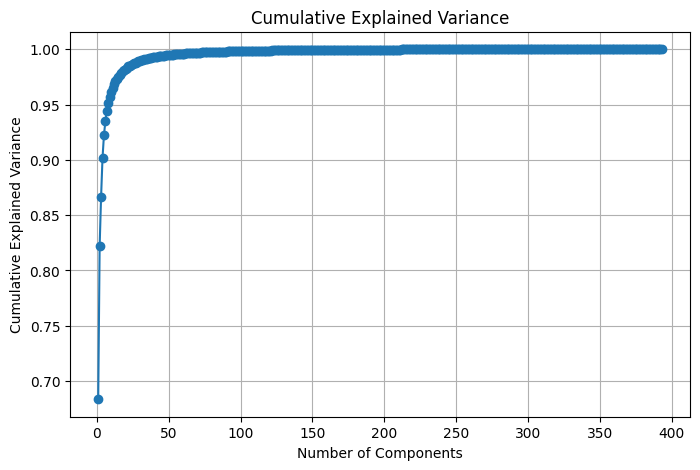

In [ ]:
#Represent the components which preserve maximum information and plot to visualize
cum_var = np.cumsum(variance)
#display(cum_var)
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of Components")                                                         #As we can see first 8 components represents 95%of the data
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [ ]:
pca=PCA(n_components=8)
reduced_data=pca.fit_transform(scaled_data)

reduced_data.shape

(393, 8)

#### Apply T-SNE and visualize with a graph (1 points)

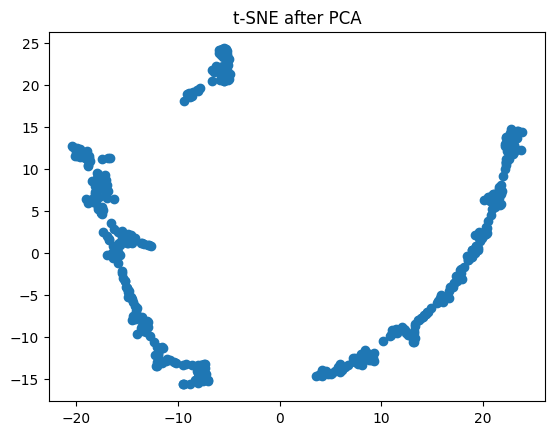

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(reduced_data)

plt.scatter(X_tsne[:,0], X_tsne[:,1])
plt.title("t-SNE after PCA")
plt.show()

**Compute the daily returns of the 500 company stocks.**

In [ ]:
# analyze pca loadings to under sector impact

# compute daily returns using df dataframe
daily_returns = df_prices.pct_change()
# drop the first row
daily_returns = daily_returns.dropna(how='any')
daily_returns.head()

# print length of dataframe
print("Length of dataframe: ", len(daily_returns))



Length of dataframe:  392


In [ ]:
# scale daily returns
daily_returns_array = daily_returns.to_numpy()
daily_returns_array = scaler.fit_transform(daily_returns_array)

# print daily returns array
print(daily_returns_array)

[[-0.88924014 -0.90139353 -0.04178641 ... -0.52075519 -0.4373901
  -0.05488535]
 [ 0.06355196 -0.2267383  -0.68530209 ...  0.19661337 -0.38016282
  -0.42195835]
 [ 0.06903073 -0.07813639 -0.50695099 ... -0.30255242 -0.19839445
   0.0966444 ]
 ...
 [-0.20207994  0.72132824 -0.19823694 ...  0.9102752   0.8345969
  -0.54703734]
 [ 0.36963526 -0.21380867  0.12155824 ...  0.08431488 -0.77771378
   0.53018126]
 [ 0.58562248  0.02154875  0.820169   ...  0.762747    0.30097555
   0.65143083]]


[0.49792089 0.07543383 0.03869192 0.02079149 0.01457552 0.01346792
 0.01233785 0.01011246 0.00928866 0.00849373 0.00814711 0.0071588
 0.00696401 0.00644412 0.00582132]
Total explained variance ratio:  73.56496355655653


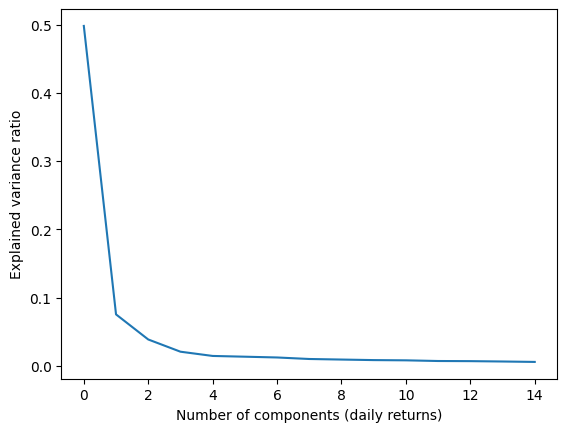

In [ ]:
# create new pca_returns variable with 15 components
pca_returns = PCA(n_components=15)

# apply pca_returns to daily returns
daily_returns_array_pca = pca_returns.fit_transform(daily_returns_array)

#print explained variance ratio
print(pca_returns.explained_variance_ratio_)

# sum up the total explained variance ratios and multiply by 100 to get a %
total_explained_variance_ratio = sum(pca_returns.explained_variance_ratio_) * 100
print("Total explained variance ratio: ", total_explained_variance_ratio)

# plot the explained variance ratio
# consider labels for x and y axis
plt.plot(pca_returns.explained_variance_ratio_)
plt.xlabel('Number of components (daily returns)')
plt.ylabel('Explained variance ratio')
plt.show()


Extract and analyze pca loadings to show how much each individual stock contributes to each principal component

1. **Extract PCA Loadings and stock names**

In [ ]:
# extract the principal components (loadings) from the pca_returns object
loadings = pca_returns.components_

# print the loadings
print(loadings)

# create a dataframe where rows are principal components and columns are stock tickets with values being the loadings
loadings_df = pd.DataFrame(loadings, columns=daily_returns.columns)

# print loadings_df length
print("Length of loadings_df: ", len(loadings_df))

loadings_df.head()


[[ 0.04814659  0.03337712  0.04491801 ...  0.04687348  0.04444495
   0.04613388]
 [ 0.05157049 -0.07155024  0.00389695 ...  0.02123573 -0.07488019
   0.05652869]
 [-0.02311914  0.00922587  0.00868482 ... -0.03344668  0.05073191
  -0.02899467]
 ...
 [ 0.04057648 -0.02997081 -0.0942031  ...  0.06094282  0.01910081
  -0.01479795]
 [ 0.05444215 -0.01893375 -0.02173219 ...  0.00138661  0.00284742
   0.04260742]
 [-0.00664262 -0.01506666  0.02566269 ... -0.05762099  0.03936781
   0.03648359]]
Length of loadings_df:  15


,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
0,0.048147,0.033377,0.044918,0.042163,0.040020,0.044474,0.025219,0.039340,0.052805,0.038672,...,0.043482,0.035038,0.047287,0.045153,0.053173,0.046768,0.045546,0.046873,0.044445,0.046134
1,0.051570,-0.071550,0.003897,0.063662,0.032046,0.029582,0.037822,0.078336,0.029361,0.074282,...,0.066356,0.051360,-0.052511,-0.040152,-0.000933,-0.010311,-0.037022,0.021236,-0.074880,0.056529
2,-0.023119,0.009226,0.008685,-0.057420,-0.008835,0.044338,-0.036105,0.010596,-0.026007,-0.093327,...,0.073350,-0.084901,0.013388,0.009850,0.031981,-0.023371,-0.036992,-0.033447,0.050732,-0.028995
3,-0.053986,-0.033940,0.049517,-0.029118,-0.003069,-0.022198,-0.009966,-0.018320,-0.010288,-0.031317,...,0.080354,-0.088082,-0.054708,0.013939,-0.022874,0.076257,0.035318,-0.073330,-0.068505,0.042721
4,0.016705,0.076211,0.042718,0.007282,-0.064674,-0.047357,0.059832,0.031506,-0.024342,-0.054240,...,-0.007043,0.019314,-0.068874,-0.022208,0.029285,0.073780,0.004068,0.040210,-0.009885,0.031671


2. **Identify Top Influential Stocks per Component**

In [ ]:
# for the first few principal components (e.g., PC1, PC2 etc.,)
# identify the stocks with highest absolute loading values
for i in range(15):
  print(f"Top 5 stocks for PC{i+1}:")
  print(loadings_df.iloc[i].abs().sort_values(ascending=False).head(5))
  print()

Top 5 stocks for PC1:
AMP    0.057807
DOV    0.057579
AME    0.056461
GL     0.056378
PH     0.055857
Name: 0, dtype: float64

Top 5 stocks for PC2:
CHD     0.098443
CLX     0.094505
EQIX    0.091845
ATVI    0.091010
COST    0.088872
Name: 1, dtype: float64

Top 5 stocks for PC3:
ED      0.130745
CMG     0.122355
PENN    0.113854
WEC     0.110293
ATO     0.106418
Name: 2, dtype: float64

Top 5 stocks for PC4:
O       0.134138
PNW     0.116163
NTAP    0.114727
MRO     0.109995
WBA     0.102704
Name: 3, dtype: float64

Top 5 stocks for PC5:
CARR    0.170867
OTIS    0.142264
OKE     0.122402
WHR     0.117579
CBOE    0.114456
Name: 4, dtype: float64

Top 5 stocks for PC6:
BKNG    0.128961
REG     0.119348
EQR     0.115680
HST     0.115517
UDR     0.114675
Name: 5, dtype: float64

Top 5 stocks for PC7:
DLTR    0.123029
TFX     0.122294
APA     0.120449
EW      0.119407
HES     0.115682
Name: 6, dtype: float64

Top 5 stocks for PC8:
CAG    0.210862
CPB    0.173412
AAL    0.147293
UAL    0.14

These stocks are the most influential for that particular component, indicating their strong correlation with the patterns captured by that component.

3. **Visualize Top Loadings**

In [ ]:
# Create a visualization (e.g., bar plots) to display the top N positive and
# top N negative loadings for the first principal component
plt.figure(figsize=(100, 100))
for i in range(15):
  plt.subplot(3, 5, i+1)
  plt.bar(loadings_df.columns, loadings_df.iloc[i].abs().sort_values(ascending=False))
  plt.title(f'PC{i+1}')
  plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Discuss Influential Stocks and Potential Sector Impact**

Upon observation,

1. The first principal component has a mix of 'financial services' and 'manufacturing' sector stocks
2. The second principal component has a tech stocks
3. There isn't a single stock that is most influential across other principal components


## Anomaly Detection (PART-B)

### Load and Preprocess the data

* Inspect the S&P 500 Index Data

In [ ]:
path = 'SPY.csv'

In [ ]:
# YOUR CODE HERE

df_spy=pd.read_csv(path)
display(df_spy.head())
display(df_spy.isnull().sum().sum())                                            #0 Nan's.
display(df_spy.shape)                                                           #7134 Rows and 7 columns

,Date,Open,High,Low,Close,Adj Close,Volume
0,1993-02-01,43.96875,44.25000,43.96875,44.25000,25.983273,480500
1,1993-02-02,44.21875,44.37500,44.12500,44.34375,26.038315,201300
2,1993-02-03,44.40625,44.84375,44.37500,44.81250,26.313566,529400
3,1993-02-04,44.96875,45.09375,44.46875,45.00000,26.423655,531500
4,1993-02-05,44.96875,45.06250,44.71875,44.96875,26.405315,492100


np.int64(0)

(7134, 7)

#### Data Preprocessing (0.5 point)

In [ ]:
# Split the data into test and train and then standardize.

df_spy_updated=df_spy[["Open","High","Low","Close","Adj Close","Volume"]]
df_spy_updated = df_spy_updated.pct_change().dropna()
#df_spy_updated["Volume"]=np.log1p(df_spy_updated["Volume"])
#df_spy_updated=df_spy[["Open","High","Low","Close","Adj Close"]]
#display(df_spy_updated.head())
#display(df_spy_updated.shape)                                                      #6 columns after dropping the date  feature as it is not understood by LSTM.

length=df_spy_updated.shape[0]
size=round(length*0.85)
train=df_spy_updated.iloc[0:size]
display(train.shape)                                                             #6064, 6
display(train.head())

test=df_spy_updated.iloc[size:]
display(test.shape)                                                             #1070,6

#verify the last & first row of both the datasets
display(train.tail(1))
display(test.head(1))


(6063, 6)

,Open,High,Low,Close,Adj Close,Volume
1,0.005686,0.002825,0.003554,0.002119,0.002118,-0.581061
2,0.004240,0.010563,0.005666,0.010571,0.010571,1.629906
3,0.012667,0.005575,0.002113,0.004184,0.004184,0.003967
4,0.000000,-0.000693,0.005622,-0.000694,-0.000694,-0.074130
5,0.000000,0.001387,0.004193,0.000000,0.000000,0.211339


(1070, 6)

,Open,High,Low,Close,Adj Close,Volume
6063,0.000127,-0.001517,-0.001396,-0.002699,-0.002699,0.715672


,Open,High,Low,Close,Adj Close,Volume
6064,0.007268,0.014222,0.009957,0.013998,0.013997,0.538318


In [ ]:
df_spy_updated.head(5)

,Open,High,Low,Close,Adj Close,Volume
1,0.005686,0.002825,0.003554,0.002119,0.002118,-0.581061
2,0.004240,0.010563,0.005666,0.010571,0.010571,1.629906
3,0.012667,0.005575,0.002113,0.004184,0.004184,0.003967
4,0.000000,-0.000693,0.005622,-0.000694,-0.000694,-0.074130
5,0.000000,0.001387,0.004193,0.000000,0.000000,0.211339


In [ ]:
#Standardize the data with the StandardScaler
# scaler=StandardScaler()
# train_scaled=scaler.fit_transform(train)
# test_scaled=scaler.transform(test)


In [ ]:
#Using Min Max Scaler
scaler=MinMaxScaler()
train_scaled=scaler.fit_transform(train)
test_scaled=scaler.transform(test)
print(train_scaled[0])
print(test_scaled[0])

[0.55195726 0.50006211 0.53298106 0.41275694 0.41275554 0.00886913]
[0.55841793 0.57498253 0.56775257 0.46151178 0.46151118 0.03334414]


### Create time series data ( 0.5 point)

Select the variable (column) from the data and create the series of data with a window size.

Refer [LSTM Autoencoder](https://medium.com/swlh/time-series-anomaly-detection-with-lstm-autoencoders-7bac1305e713)

In [ ]:
# Writing a custom function to create windows of size 30.
def create_windows(data,window_size):
  X=[]
  for i in range (len(data)- window_size):
    window=data[i:i+window_size]
    X.append(window)

  return np.array(X)

In [ ]:
#Creating the train and test input
X_train=create_windows(train_scaled,30)
display(X_train.shape)                                                         #6034 samples, with 30 timesteps and 6 features.
X_test=create_windows(test_scaled,30)
display(X_test.shape)                                                          #1040 samples with 30 timesteps and 6 features.

(6033, 30, 6)

(1040, 30, 6)

### Build an LSTM Autoencoder ( 1 points)

Autoencoder should take a sequence as input and outputs a sequence of the same shape.

Hint: [LSTM Autoencoder](https://medium.com/swlh/time-series-anomaly-detection-with-lstm-autoencoders-7bac1305e713)

In [ ]:
timesteps=X_train.shape[1]
n_features=X_train.shape[2]
model=Sequential()
##Adding the Encoder layer
model.add(tf.keras.layers.LSTM(128,input_shape=(timesteps,n_features),activation='tanh',return_sequences=True))
model.add(tf.keras.layers.LSTM(64,activation='tanh',return_sequences=True))
model.add(tf.keras.layers.LSTM(32,activation='tanh'))
#model.add(tf.keras.layers.Dropout(0.1))

#creating an input for decoder with (30,64) size.
model.add(tf.keras.layers.RepeatVector(timesteps))

#Decoder
model.add(tf.keras.layers.LSTM(128,activation='tanh',return_sequences=True))
model.add(tf.keras.layers.LSTM(64,return_sequences=True,activation='tanh'))
model.add(tf.keras.layers.LSTM(32,return_sequences=True,activation='tanh'))
#model.add(tf.keras.layers.Dropout(0.1))

#output per timestamp
model.add(tf.keras.layers.TimeDistributed(Dense(n_features)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 6)          │           198 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,398 (1.05 MB)

 Trainable params: 275,398 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Autoencoder (1 point)

* Compile and fit the model with required parameters

In [ ]:
# optimizer = tf.keras.optimizers.Adam(
#     learning_rate=0.0005
# )
model.compile(optimizer='adam',loss='mse')

In [ ]:
history=model.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=32,
    #validation_split=0.1,
    shuffle=False
)

Epoch 1/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0024
Epoch 2/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 3/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0024
Epoch 4/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 5/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 6/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 7/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0024
Epoch 8/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 9/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 10/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 11/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0024
Epoch 12/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 13/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0024
Epoch 14/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0024
Epoch 15/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3

#### Plot metrics and evaluate the model (1 point)

In [ ]:
#Fit the model on test dataset
X_pred = model.predict(X_test)
#display(X_pred[0])
display(X_pred.shape)
#print(np.std(X_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


(1040, 30, 6)

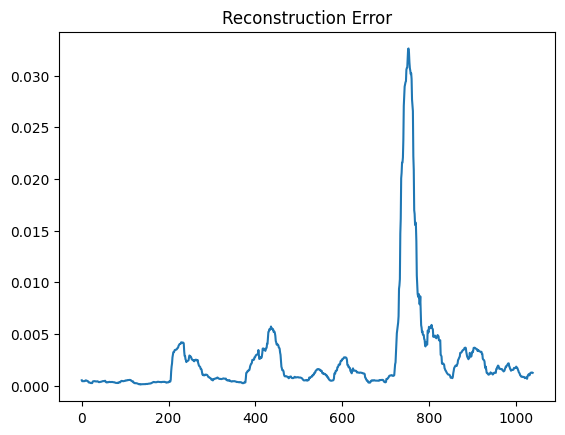

In [ ]:
mse = np.mean(np.square(X_test - X_pred), axis=(1,2))             #reconsturction error
plt.plot(mse)
plt.title("Reconstruction Error")
plt.show()

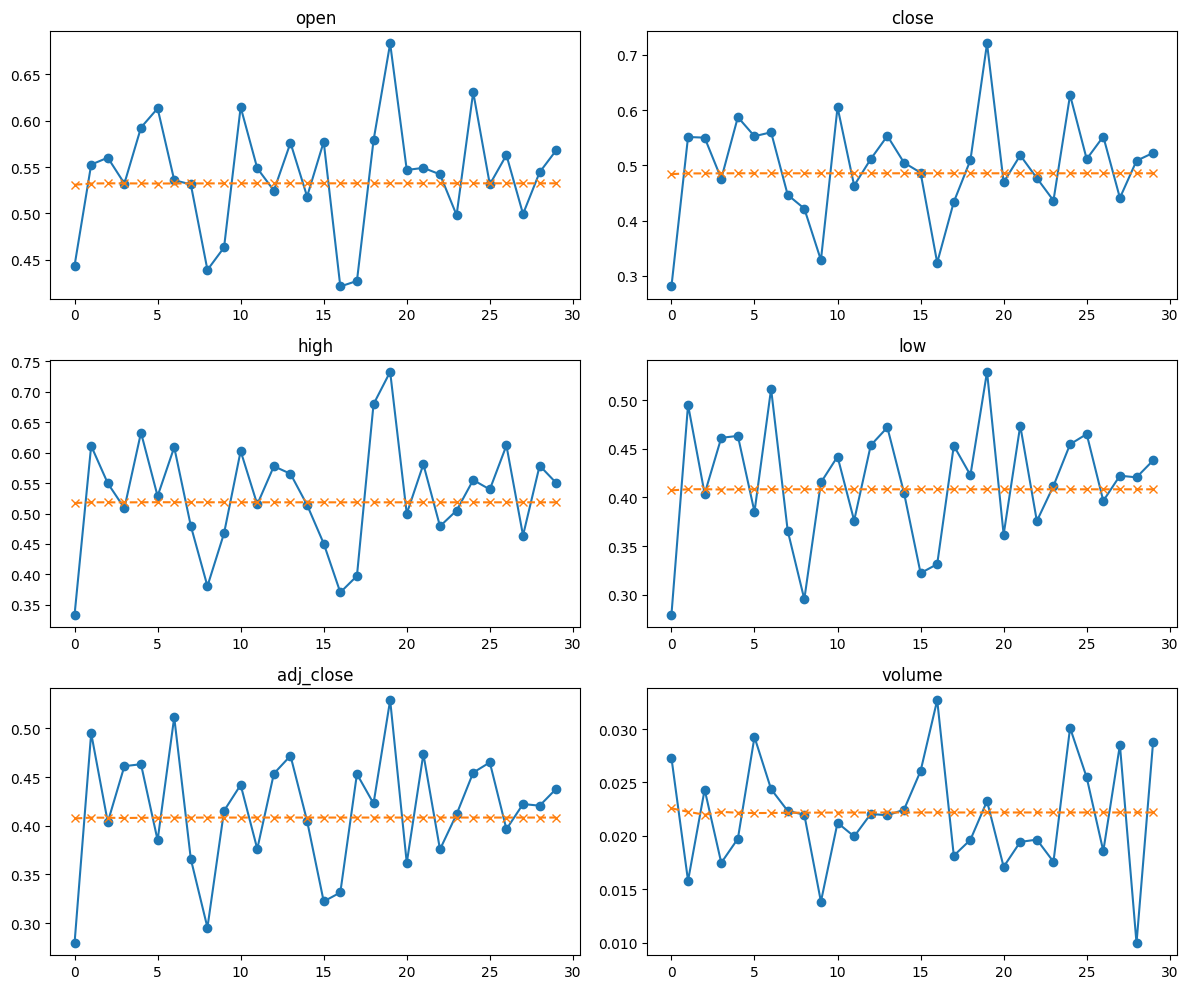

In [ ]:
sample_idx=790
feature_names = ["open","close","high","low","adj_close","volume"]

plt.figure(figsize=(12,10))

for i in range(6):
    plt.subplot(3,2,i+1)

    plt.plot(X_test[sample_idx][:, i], label="Original",marker='o')
    plt.plot(X_pred[sample_idx][:, i], "--", label="Reconstructed",marker='x')

    plt.title(feature_names[i])

plt.tight_layout()
plt.show()

### Detect Anomalies in the S&P 500 Index Data (1.5 points)

* Predict the data and calculate the loss
* Define threshold and detect the anomalies

Discuss the Impact of COVID19 pandemic on stock prices in terms of anomalies detected during the pandemic period in stock prices

In [ ]:
anomaly_score=np.mean(
    np.square(X_test - X_pred),
    axis=(1,2))

print(anomaly_score.shape )                                     #1 score per window.
threshold=np.percentile(anomaly_score,95)
anomalies = anomaly_score > threshold
print(threshold)
print(anomalies)

(1040,)
0.006107170272059354
[False False False ... False False False]


In [ ]:
X_pred = model.predict(X_test)

mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))
print("MSE shape:", mse.shape)
threshold = np.percentile(mse, 95)  # top 5% treated as anomaly
print("Threshold:", threshold)
anomalies = mse > threshold
print("Number of anomalies:", np.sum(anomalies))


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MSE shape: (1040,)
Threshold: 0.006107170272059354
Number of anomalies: 52


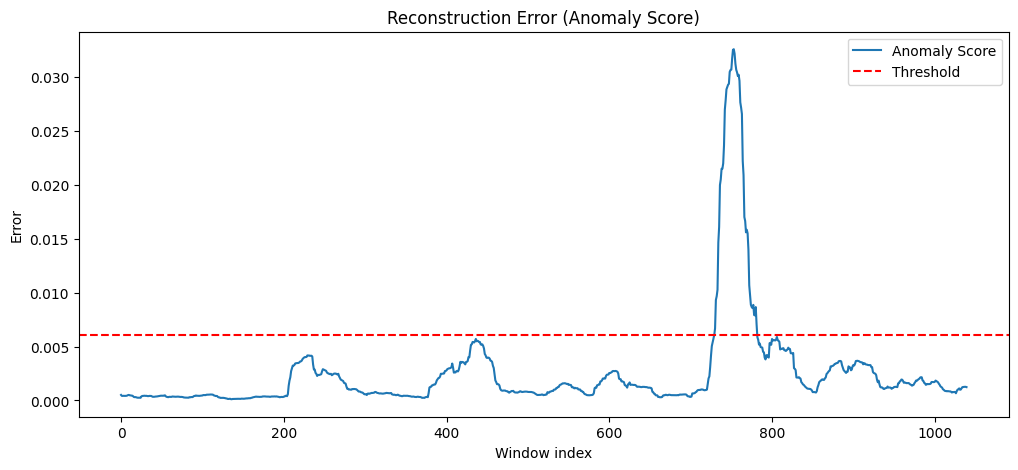

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(anomaly_score, label="Anomaly Score")
plt.axhline(threshold,
            color='red',
            linestyle='--',
            label='Threshold')

plt.title("Reconstruction Error (Anomaly Score)")
plt.xlabel("Window index")
plt.ylabel("Error")
plt.legend()
plt.show()

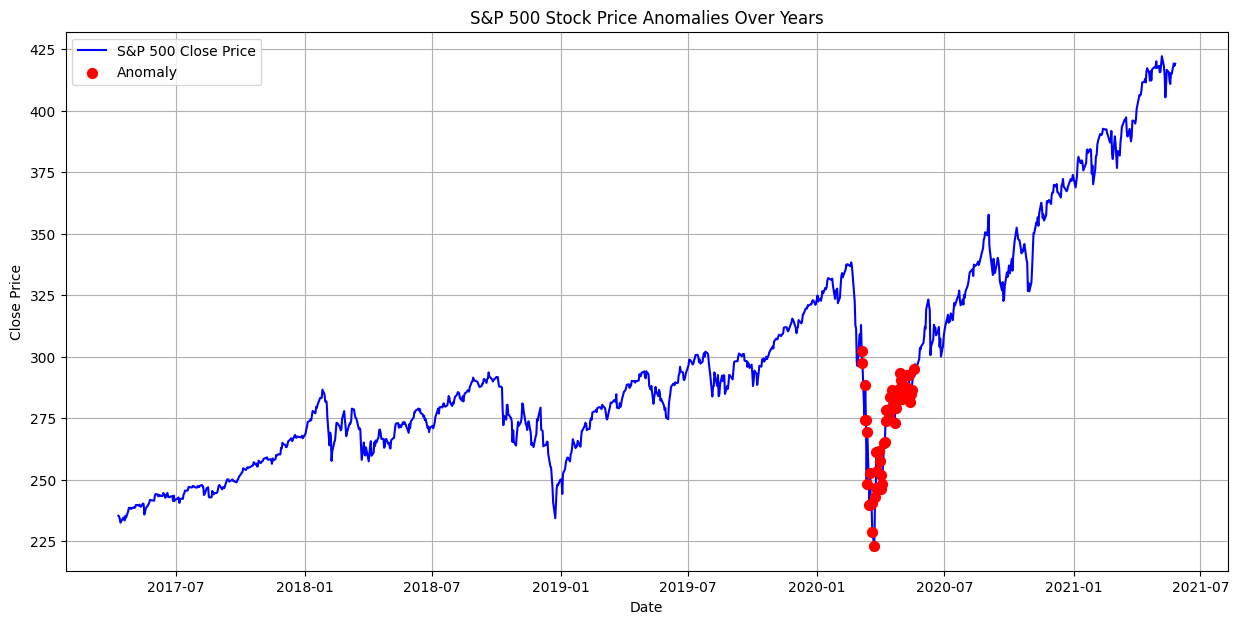

In [ ]:
window_size = 30

# Get the full test dataset including the 'Date' column
df_test_full = df_spy.iloc[size:].copy()

# The anomalies correspond to the end of each window in X_test
# Adjust the index to align anomaly scores with the correct dates
# The first anomaly score corresponds to the 30th day (index 29) of the test set

anomaly_indices_in_test_df = np.arange(window_size - 1, len(df_test_full) - (window_size - 1)) # Adjusted this logic

# Filter the dates and close prices for the range where anomalies are calculated
plot_dates = df_test_full['Date'].iloc[window_size-1:window_size-1+len(anomalies)]
plot_close = df_test_full['Close'].iloc[window_size-1:window_size-1+len(anomalies)]

# Create a dataframe for plotting anomalies
anomaly_data = pd.DataFrame({
    'Date': plot_dates,
    'Close': plot_close,
    'Anomaly': anomalies
})

# Filter for actual anomalies
anomalies_to_plot = anomaly_data[anomaly_data['Anomaly'] == True]

plt.figure(figsize=(15, 7))
plt.plot(pd.to_datetime(plot_dates), plot_close, label='S&P 500 Close Price', color='blue')
plt.scatter(pd.to_datetime(anomalies_to_plot['Date']), anomalies_to_plot['Close'],
            color='red', label='Anomaly', s=50, zorder=5)

plt.title('S&P 500 Stock Price Anomalies Over Years')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
feature_error = np.mean(
    np.square(X_test - X_pred),
    axis=1
)

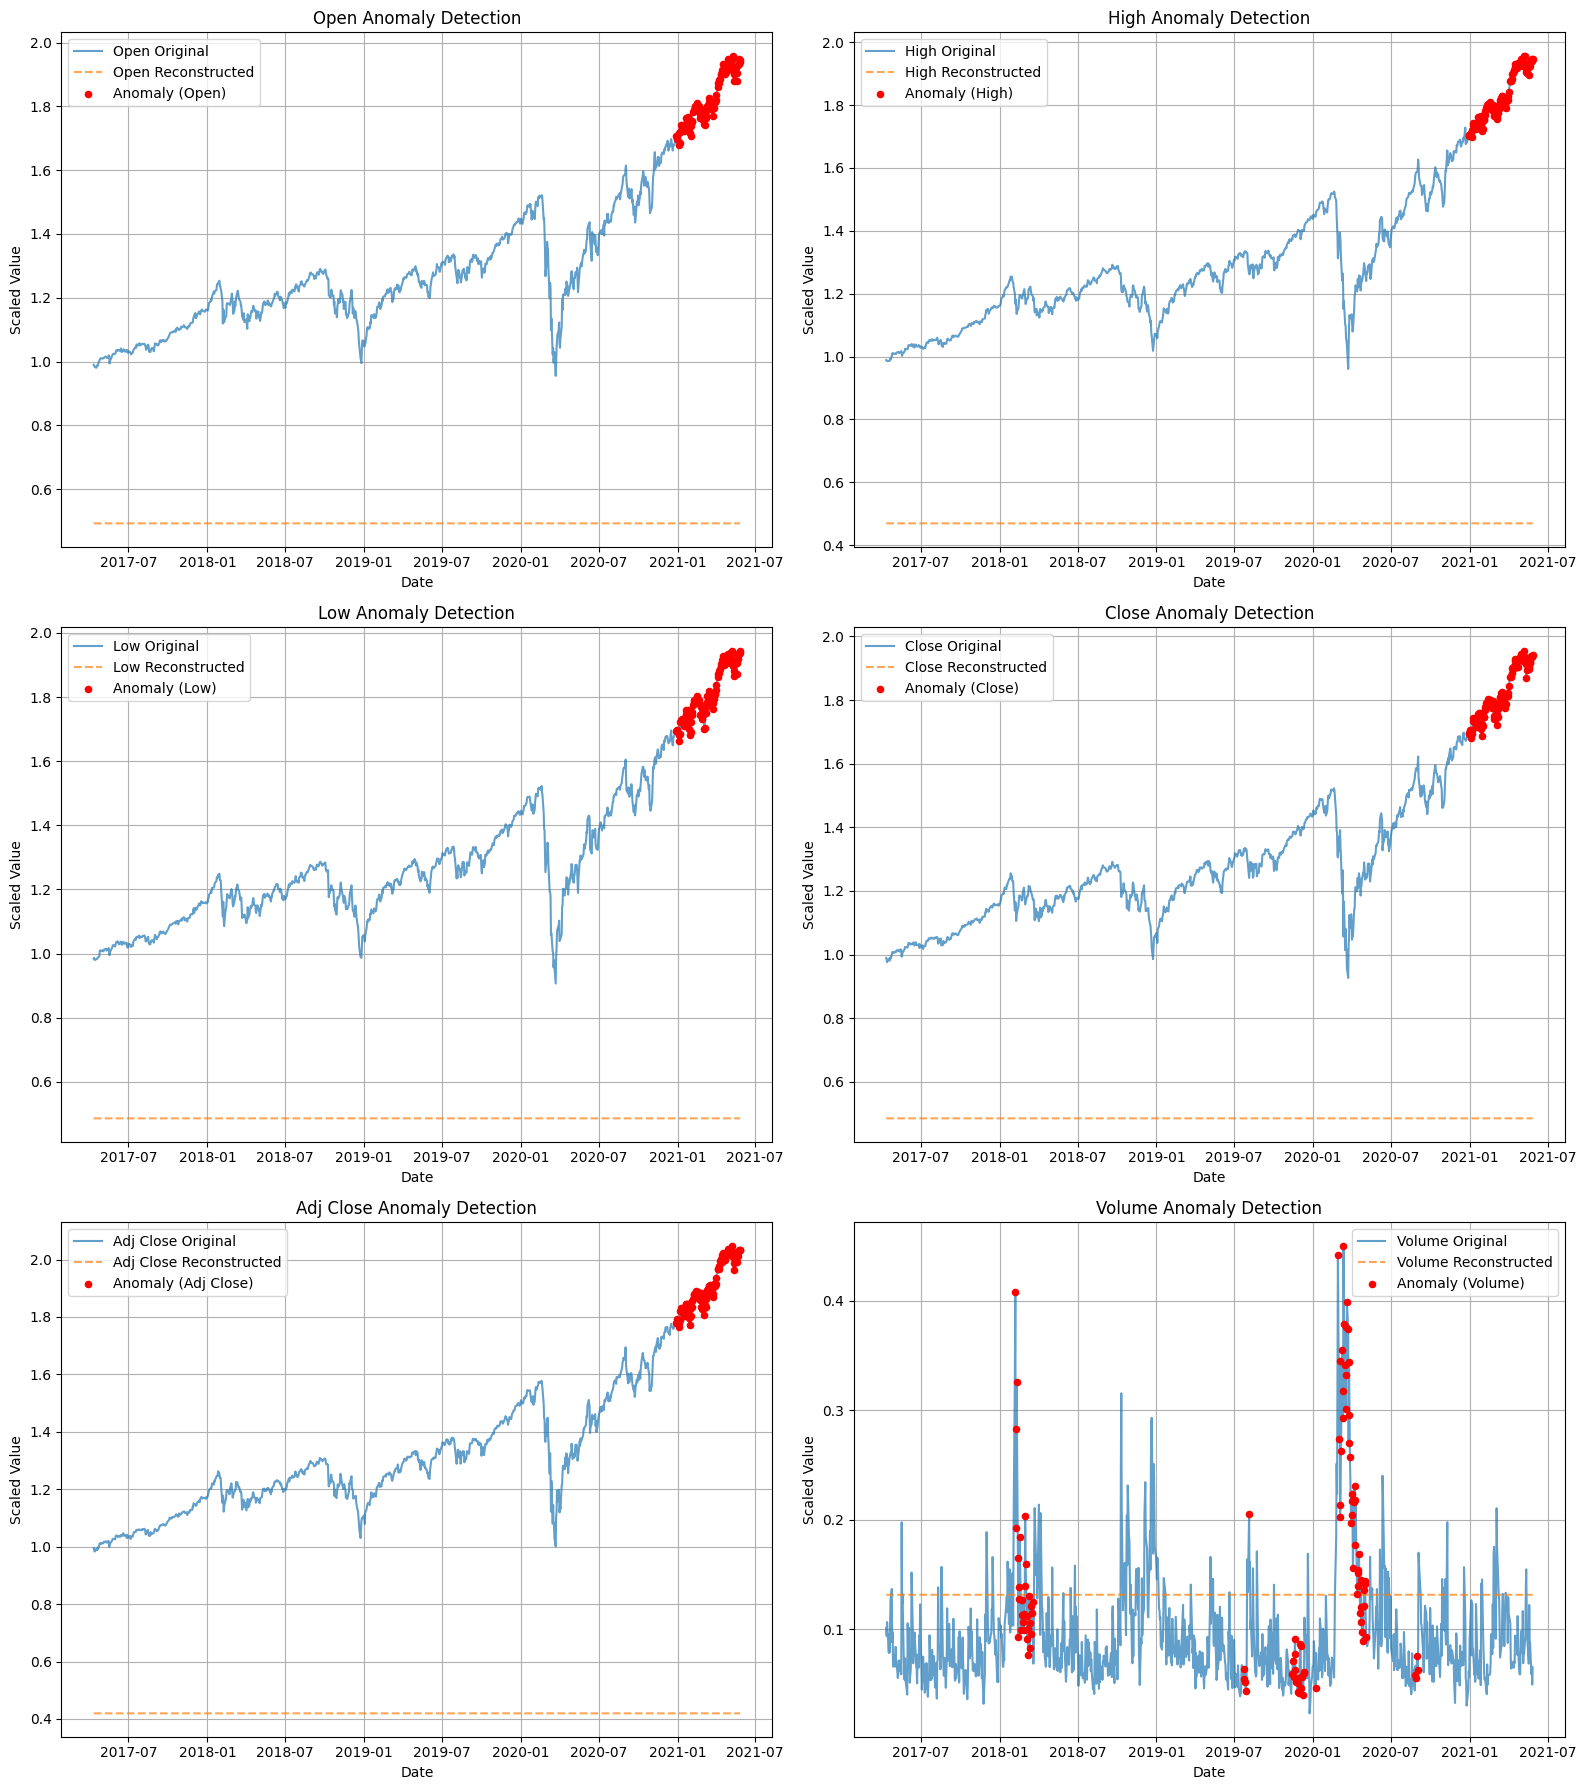

In [ ]:
plt.figure(figsize=(16, 18)) # Adjust figure size for better readability of 6 subplots
feature_names = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

for i, feature in enumerate(feature_names):
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns

    # Get the actual values for the feature from the last element of each window
    original_values = X_test[:, -1, i]
    reconstructed_values = X_pred[:, -1, i]

    # Calculate feature-specific anomaly threshold and anomalies
    feature_mse = feature_error[:, i] # This is the MSE for feature 'i' across all windows
    threshold_feature = np.percentile(feature_mse, 90) # Top 10% reconstruction error for this specific feature
    anomalies_feature = feature_mse > threshold_feature

    # Plot original and reconstructed values
    plt.plot(pd.to_datetime(plot_dates), original_values, label=f'{feature} Original', alpha=0.7)
    plt.plot(pd.to_datetime(plot_dates), reconstructed_values, label=f'{feature} Reconstructed', linestyle='--', alpha=0.7)

    # Highlight anomalies for this specific feature
    anomalous_dates_feature = plot_dates[anomalies_feature]
    anomalous_original_values_feature = original_values[anomalies_feature]
    plt.scatter(pd.to_datetime(anomalous_dates_feature), anomalous_original_values_feature,
                color='red', label=f'Anomaly ({feature})', s=20, zorder=5)

    plt.title(f'{feature} Anomaly Detection')
    plt.xlabel('Date')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Report Analysis

* Discuss on the results of T-SNE and PCA
* Dicuss about the results of LSTM autoencoder